In [1]:
# Imports

import helpers.helper_functions as hf
import mne
import matplotlib.pyplot as plt
import os.path as op


ss = hf.settings_dict()

loading raw dataset for subject:  0005_3SJ
Reading /media/elias/Personal Data/Documents/masters/Thesis/data/scratch/epochs/0005_3SJ-raw.fif ...


/tmp/ipykernel_51555/129525413.py:6: RuntimeWarning: This filename (/media/elias/Personal Data/Documents/masters/Thesis/data/scratch/epochs/0005_3SJ-raw.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(op.join(ss['epochs_dir'],subject+"-raw.fif"), preload=True)


    Found the data of interest:
        t =    -500.00 ...    4500.00 ms
        0 CTF compensation matrices available
Not setting metadata
70 matching events found
No baseline correction applied
0 projection items activated
(70, 210, 10001)
<Info | 24 non-empty values
 acq_pars: ACQactiveGround 0 ACQch.BIO001.gain 2000 ACQch.BIO001.highpass ...
 bads: 1 items (MEG1143)
 ch_names: EMG001, EMG002, EOG003, EOG004, MEG0112, MEG0113, MEG0122, ...
 chs: 2 EEG, 2 EOG, 204 Gradiometers, 1 misc, 1 Stimulus
 custom_ref_applied: False
 description: TRIUX system at Aarhus
 dev_head_t: MEG device -> head transform
 dig: 187 items (3 Cardinal, 4 HPI, 180 Extra)
 events: 1 item (list)
 experimenter: Sarang Dalal (sarang)
 file_id: 4 items (dict)
 gantry_angle: 68.0
 highpass: 38.0 Hz
 hpi_meas: 1 item (list)
 hpi_results: 1 item (list)
 hpi_subsystem: 3 items (dict)
 line_freq: 50.0
 lowpass: 42.0 Hz
 meas_date: 2018-05-14 13:03:30 UTC
 meas_id: 4 items (dict)
 nchan: 210
 proj_id: 52
 proj_name: fl

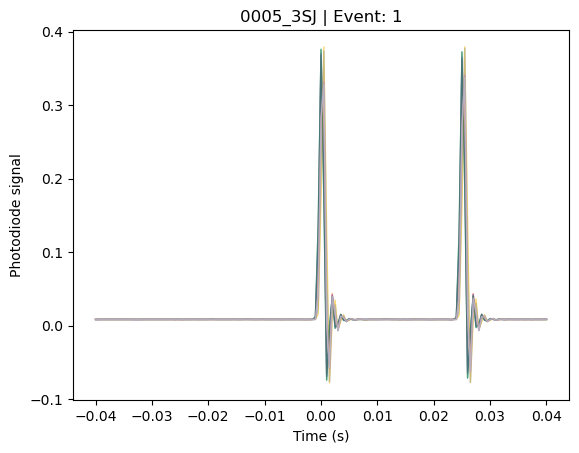

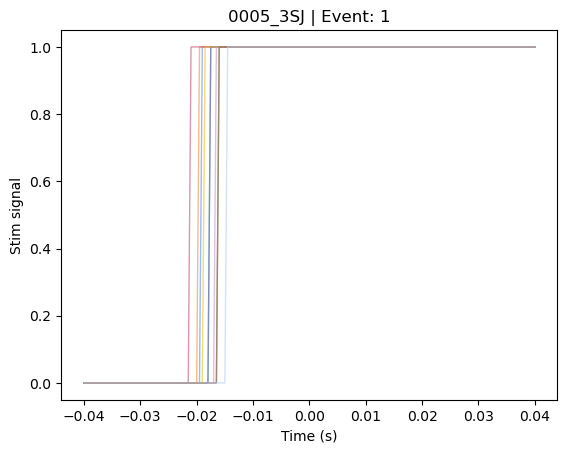

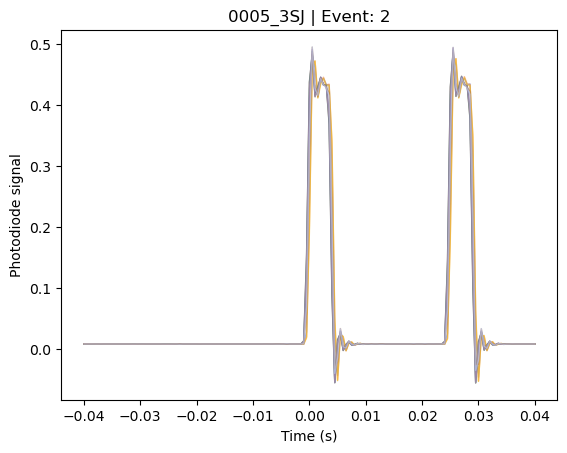

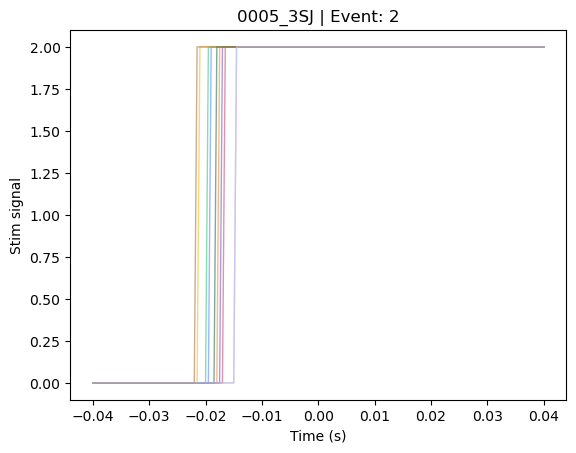

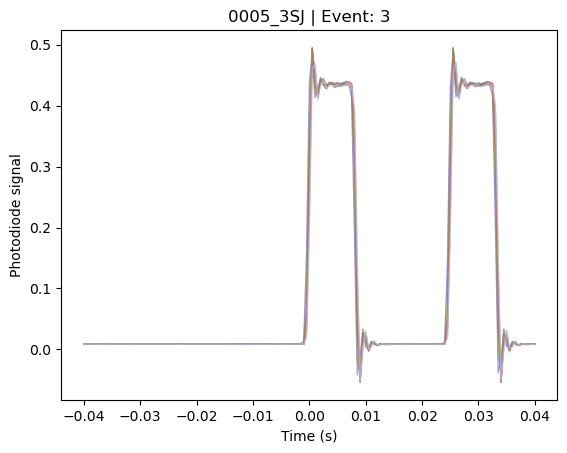

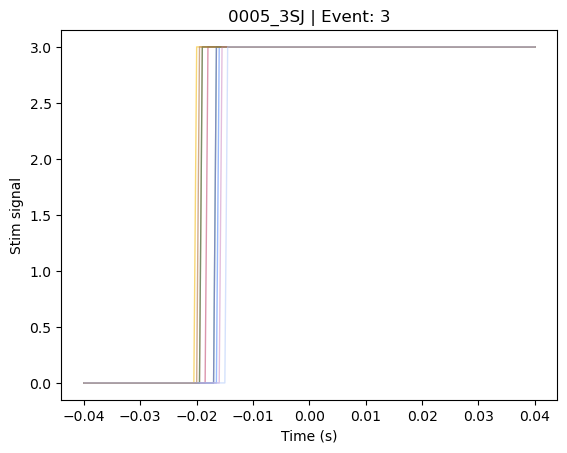

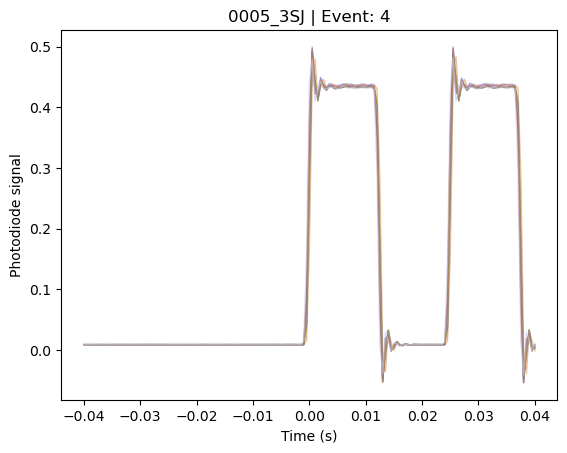

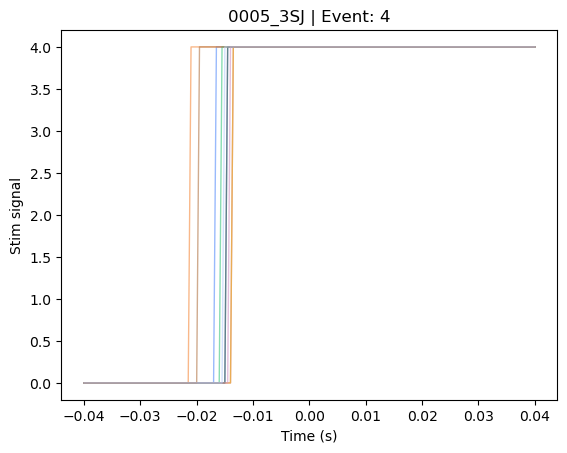

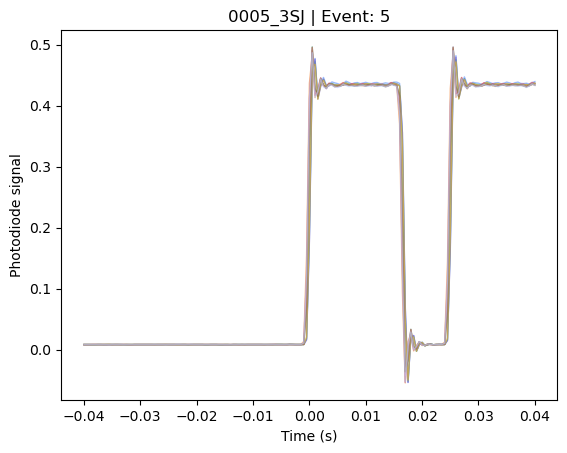

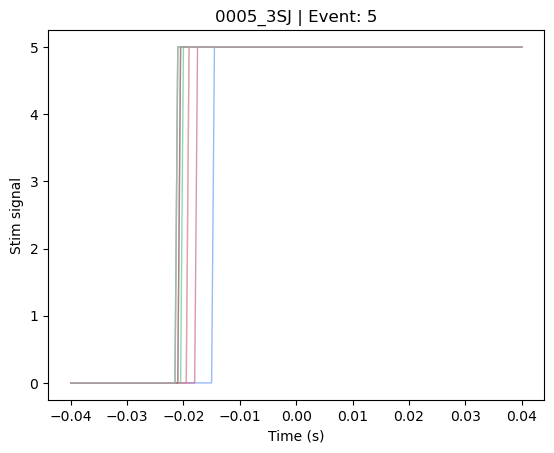

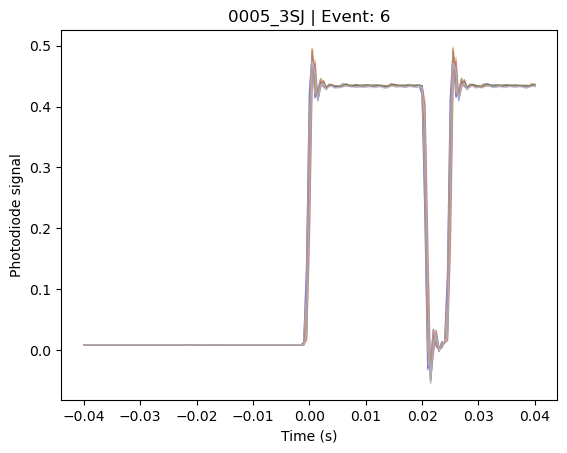

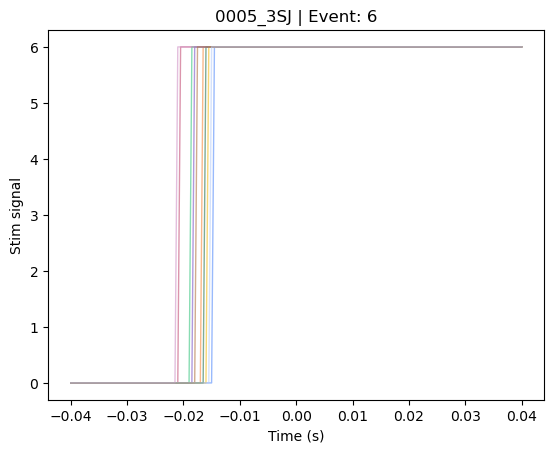

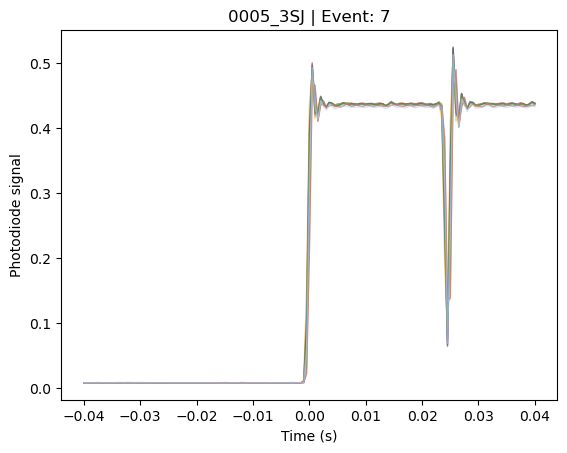

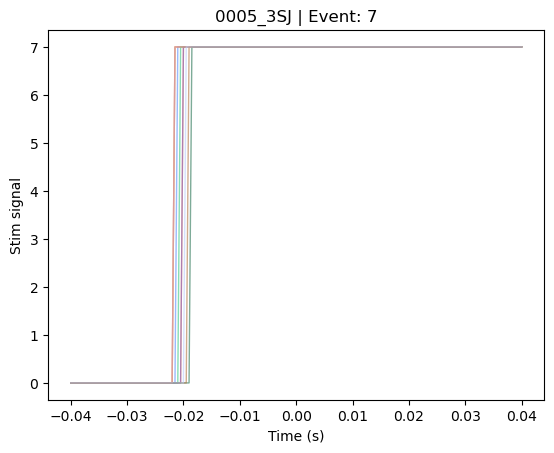

loading raw dataset for subject:  0002_TCZ
Reading /media/elias/Personal Data/Documents/masters/Thesis/data/scratch/epochs/0002_TCZ-raw.fif ...


/tmp/ipykernel_51555/129525413.py:6: RuntimeWarning: This filename (/media/elias/Personal Data/Documents/masters/Thesis/data/scratch/epochs/0002_TCZ-raw.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(op.join(ss['epochs_dir'],subject+"-raw.fif"), preload=True)


    Found the data of interest:
        t =    -500.00 ...    4500.00 ms
        0 CTF compensation matrices available
Not setting metadata
70 matching events found
No baseline correction applied
0 projection items activated
(70, 210, 10001)
<Info | 24 non-empty values
 acq_pars: ACQactiveGround 0 ACQch.BIO001.gain 2000 ACQch.BIO001.highpass ...
 bads: 1 items (MEG1143)
 ch_names: EMG001, EMG002, EOG003, EOG004, MEG0112, MEG0113, MEG0122, ...
 chs: 2 EEG, 2 EOG, 204 Gradiometers, 1 misc, 1 Stimulus
 custom_ref_applied: False
 description: TRIUX system at Aarhus
 dev_head_t: MEG device -> head transform
 dig: 139 items (3 Cardinal, 4 HPI, 132 Extra)
 events: 1 item (list)
 experimenter: Marie Louise Holm Moller (marielouise)
 file_id: 4 items (dict)
 gantry_angle: 68.0
 highpass: 38.0 Hz
 hpi_meas: 1 item (list)
 hpi_results: 1 item (list)
 hpi_subsystem: 3 items (dict)
 line_freq: 50.0
 lowpass: 42.0 Hz
 meas_date: 2018-05-22 10:47:18 UTC
 meas_id: 4 items (dict)
 nchan: 210
 proj_id: 

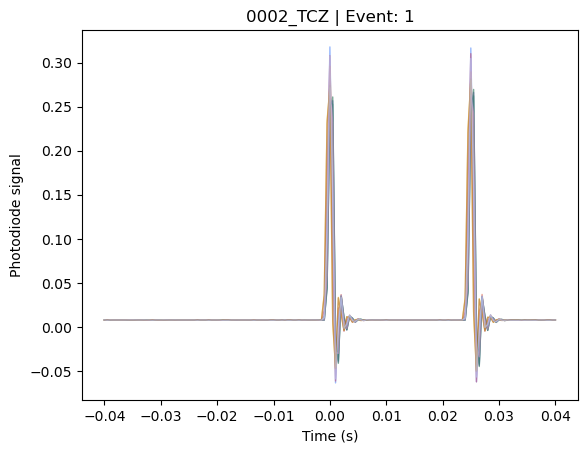

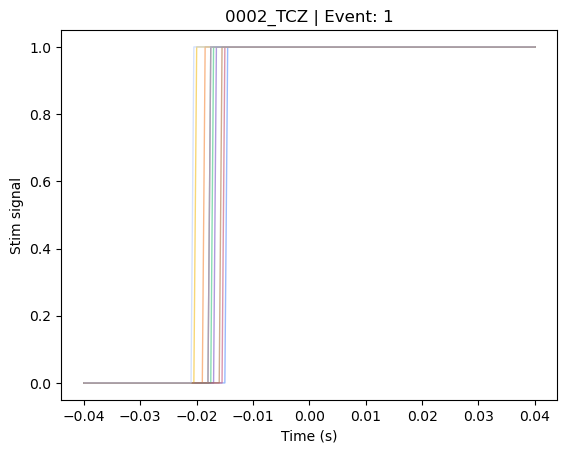

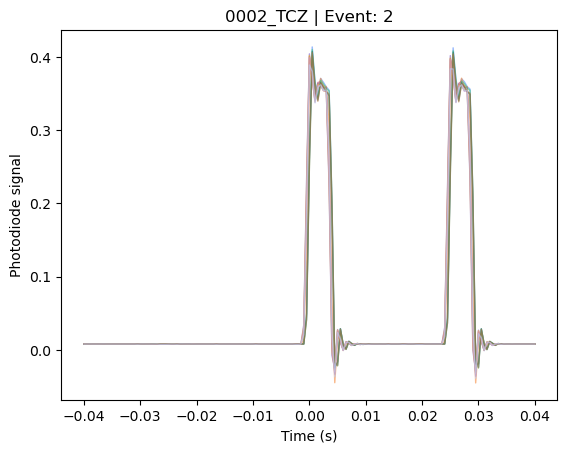

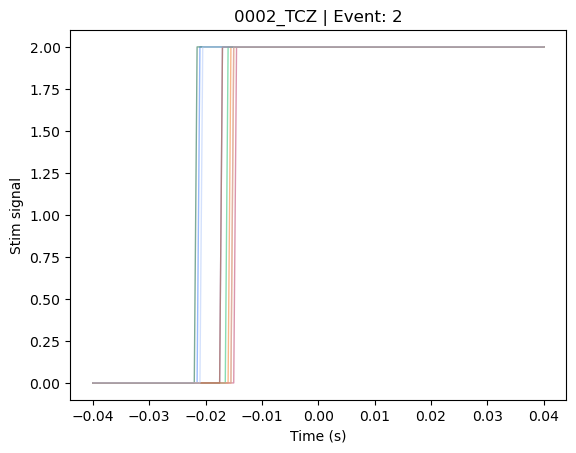

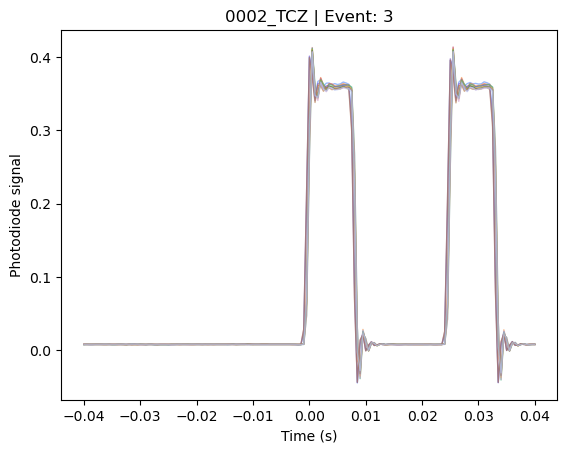

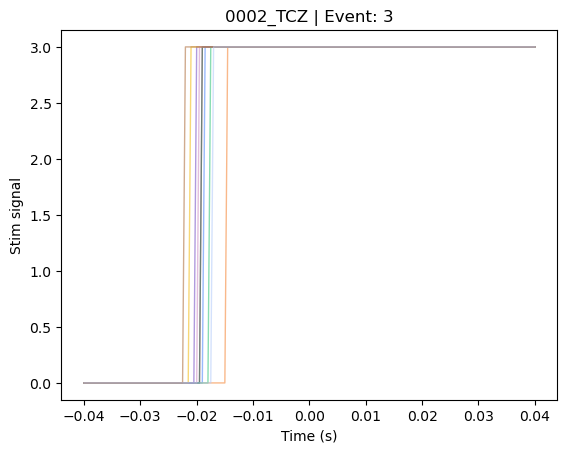

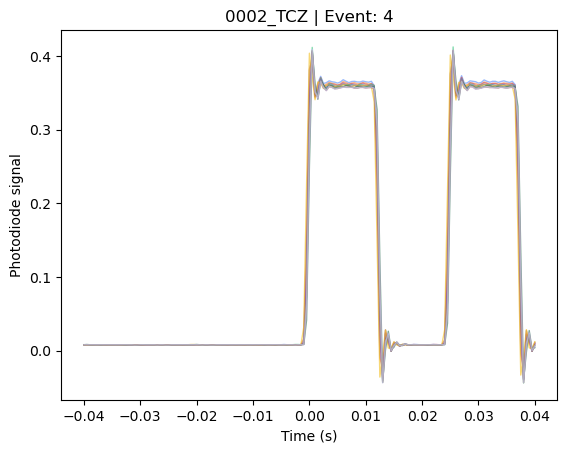

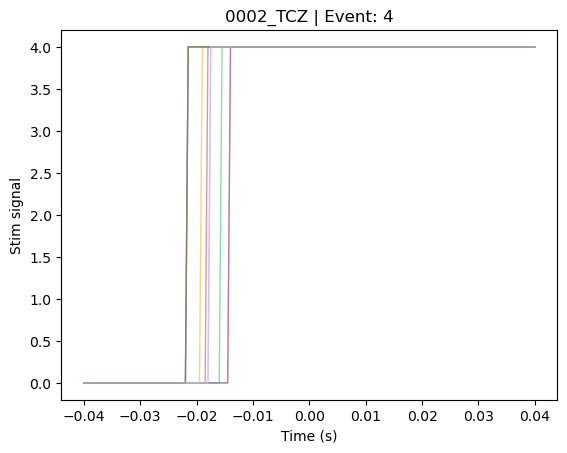

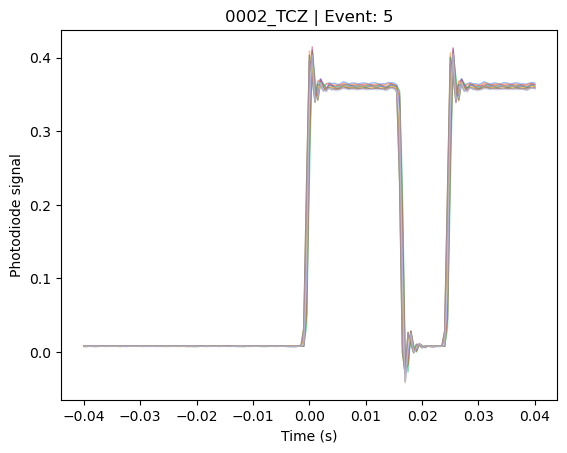

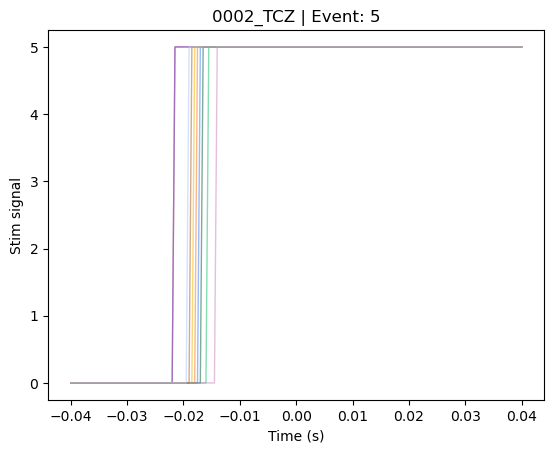

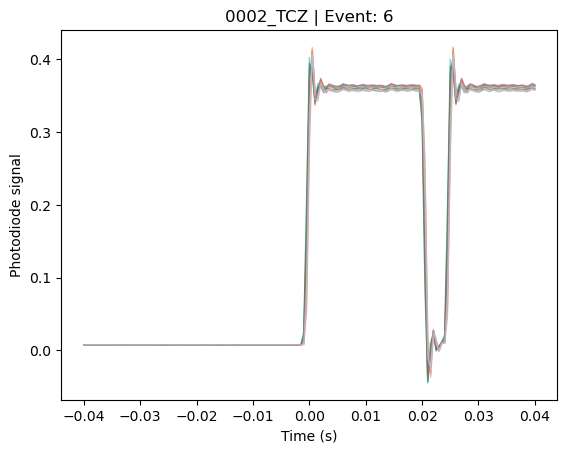

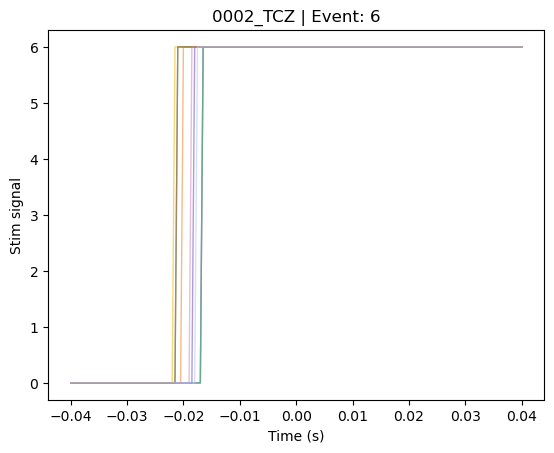

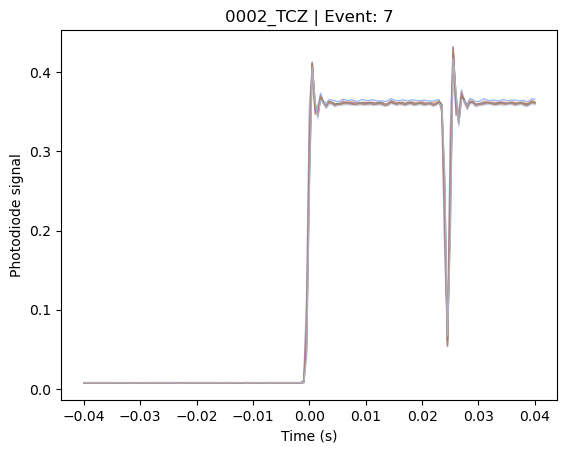

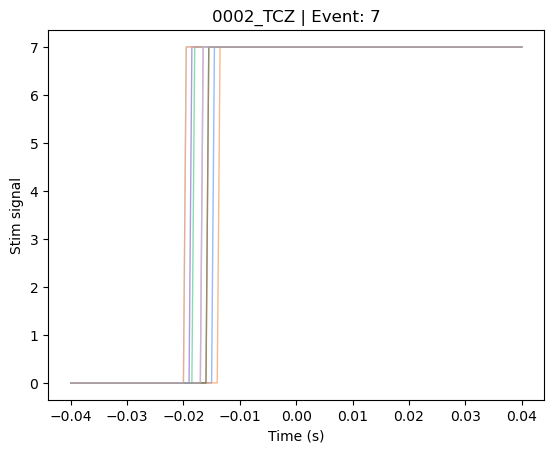

In [2]:
for subject_index in ss['subject_idx_list']:

    subject = ss['subject_id_list'][subject_index]
    print("loading raw dataset for subject: ", subject)

    epochs = mne.read_epochs(op.join(ss['epochs_dir'],subject+"-raw.fif"), preload=True)

    print(epochs.get_data().shape)
    print(epochs.info)

    # TODO: clean this up

    # epochs.plot(picks=['stim', 'misc'], title=subject + " stimulus/ misc alignment")

    times = epochs.copy().crop(-0.04, 0.04).times

    # loop over each event type
    for event_name in epochs.event_id.keys():

        # extract misc channel
        diode_epochs = epochs[event_name].copy().crop(-0.04, 0.04).pick('misc').get_data()

        # extract stim channel
        stim_epochs = epochs[event_name].copy().crop(-0.04, 0.04).pick('stim').get_data()

        # remove channel dimension
        diode_epochs = diode_epochs[:, 0, :]  # (n_epochs, n_times)
        stim_epochs = stim_epochs[:, 0, :]  # (n_epochs, n_times)


        # plot
        plt.figure()

        for ep in diode_epochs:
            plt.plot(times, ep, linewidth=1, alpha=0.6)

        plt.xlabel("Time (s)")
        plt.ylabel("Photodiode signal")
        plt.title(f"{subject} | Event: {event_name}")

        plt.show()

        plt.figure()

        for ep in stim_epochs:
            plt.plot(times, ep, linewidth=1, alpha=0.6)

        plt.xlabel("Time (s)")
        plt.ylabel("Stim signal")
        plt.title(f"{subject} | Event: {event_name}")

        plt.show()

    del epochs
